# Analysis of Current Embeddings

In [2]:
import numpy as np

EMB = "../notebooks/embeddings_sentence_transformer_ibm-granite_granite-embedding-97m-multilingual-r2.npy"

X = np.load(EMB, mmap_mode="r")

print(X.shape, X.dtype)

(247621, 384) float32


In [ ]:
# sampling the embeddings of 5000 random emails
rng = np.random.RandomState(42)
idx = np.sort(rng.choice(X.shape[0], size=5000, replace=False))

sample = np.asarray(X[idx], dtype=np.float64)

In [ ]:
# 1. normalize the sample to unit length
# 2. compute the gram matrix
# 3. extract the upper triangular part (without the diagonal)
# 4. compute the cosine similarity between the vectors

norm = sample / np.linalg.norm(sample, axis=1, keepdims=True)
gram = norm @ norm.T
iu = np.triu_indices(len(norm), k=1)
cos = gram[iu]

print(cos.size, cos.mean(), np.median(cos), cos.std(), cos.min(), cos.max())

12497500 0.7685746343474414 0.7686674571481547 0.03336583601162307 0.6007600028906123 1.0


In [5]:
print(np.linalg.norm(norm.mean(axis=0)))   # 0.876
print(1 / np.sqrt(len(norm)))              # 0.0141  (spread-out baseline)

0.8767102824882178
0.01414213562373095


## Anisotropy found! Let's see how we may resolve this...

In [6]:
# uncentered: how much energy is in the shared direction?
sv = np.linalg.svd(norm, compute_uv=False)
energy = sv ** 2
print(energy[0] / energy.sum())     # 0.768

0.7689357873051551


In [ ]:
# centered: what structure survives once the cone is removed?
centered = norm - norm.mean(axis=0)
sv2 = np.linalg.svd(centered, compute_uv=False)
var = sv2 ** 2 / (sv2 ** 2).sum()
print(var[0], var[1])
print(int(np.searchsorted(np.cumsum(var), 0.95) + 1)) 

0.05397325266396574 0.0310314300044155
155


## HBDScan and UMAP bug checks

In [ ]:
from umap import UMAP
from hdbscan import HDBSCAN

proj = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
            metric="cosine", random_state=42).fit_transform(sample)
np.save("umap5k.npy", proj)  

for mcs, ms, sel in [(2, None, "eom"), (2, 5, "eom"),
                     (25, None, "eom"), (25, 5, "leaf"),
                     (50, None, "eom"), (50, 5, "leaf")]:
    lab = HDBSCAN(min_cluster_size=mcs, min_samples=ms,
                  metric="euclidean", cluster_selection_method=sel).fit_predict(proj)
    k = len(set(lab)) - (1 if -1 in lab else 0)
    sizes = np.bincount(lab[lab >= 0])
    print(f"mcs={mcs} ms={ms} {sel}: k={k} noise={(lab == -1).mean():.1%} "
          f"largest={sizes.max() / len(lab):.1%}")

/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


mcs=2 ms=None eom: k=624 noise=30.7% largest=0.9%
mcs=2 ms=5 eom: k=247 noise=49.4% largest=0.9%
mcs=25 ms=None eom: k=4 noise=0.1% largest=96.7%
mcs=25 ms=5 leaf: k=43 noise=54.6% largest=3.1%
mcs=50 ms=None eom: k=2 noise=0.0% largest=98.3%
mcs=50 ms=5 leaf: k=19 noise=55.6% largest=5.8%


In [ ]:
from bertopic import BERTopic

MODEL = "../notebooks/emails_clustered_20260924T154513_model.pkl"   # min_cluster_size=500
topic_model = BERTopic.load(MODEL)          # ~1 minute
clusterer = topic_model.hdbscan_model

print(np.round(clusterer.cluster_persistence_, 4))

tree = clusterer.condensed_tree_.to_pandas()
n = clusterer.labels_.shape[0]
subtrees = tree[tree["child_size"] > 1]
root = subtrees.sort_values("child_size", ascending=False).iloc[0]
print(int(root.child_size), n, root.child_size / n, root["lambda_val"])
print(int((subtrees["child_size"] > n / 2).sum()))

[0.7035 0.0248 0.0953 0.0161]
242568 247621 0.9795938147410761 0.16302467898788686
14


<Axes: ylabel='$\\lambda$ value'>

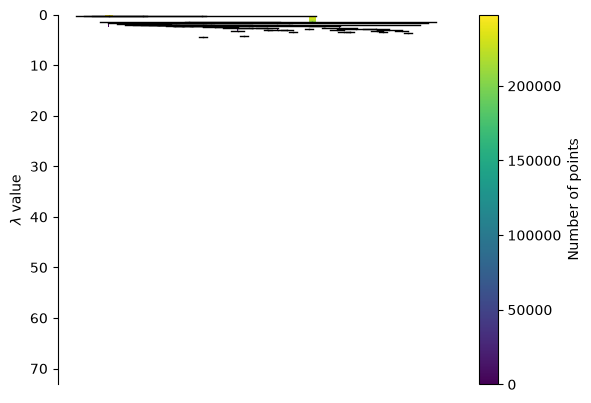

In [12]:
clusterer.condensed_tree_.plot()

Due to the uniformity of semantic data, the tree is extremely shallow. Fourteen tree nodes each hold over half the corpus

In [13]:
def peakedness(topic_model, topic_id):
    weights = [w for _, w in topic_model.get_topic(topic_id)]
    return max(weights), sum(weights) / len(weights)

for t in sorted(topic_model.get_topics()):
    top, mean = peakedness(topic_model, t)
    print(f"topic {t:2d}: top {top:.4f}  mean top-10 {mean:.4f}")

topic -1: top 0.0565  mean top-10 0.0391
topic  0: top 0.0187  mean top-10 0.0147
topic  1: top 0.4226  mean top-10 0.2808
topic  2: top 0.1867  mean top-10 0.1414
topic  3: top 0.8607  mean top-10 0.3398


## Formally evaluate embeddings and topic model using new evaluate module

In [14]:
import numpy as np, pandas as pd
from bertopic import BERTopic
from email_cls_with_clustering import evaluate as ev

STEM = "../notebooks/emails_clustered_20260924T154513"       # min_cluster_size=500
EMB = ("../notebooks/embeddings_sentence_transformer_"
       "ibm-granite_granite-embedding-97m-multilingual-r2.npy")

topic_model = BERTopic.load(f"{STEM}_model.pkl")          # ~1 minute
labels = pd.read_csv(f"{STEM}.csv", usecols=["topic"])["topic"].to_numpy()
X = np.load(EMB, mmap_mode="r")

print("diversity ", round(ev.topic_diversity(topic_model), 3))
# diversity  0.975
print("peakedness", {k: round(v, 4) for k, v in ev.peakedness(topic_model).items()})
# peakedness {0: 0.0187, 1: 0.4226, 2: 0.1867, 3: 0.8607}
#            ^ topic 0 is the 95% mega-cluster, and it is flat
print("dbcv      ", round(ev.dbcv(np.asarray(X), labels, sample=20_000), 4))

diversity  0.975
peakedness {0: np.float64(0.0187), 1: np.float64(0.4226), 2: np.float64(0.1867), 3: np.float64(0.8607)}


/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[
/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[
/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[
/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[


dbcv       -0.4197


In [16]:
from hdbscan import HDBSCAN
from hdbscan.validity import validity_index

rng = np.random.default_rng(42)
idx = np.sort(rng.choice(X.shape[0], size=5000, replace=False))
raw = np.asarray(X[idx], dtype=np.float64)                    # 5,000 x 384, original space
proj = np.load("../scratch/umap5k.npy").astype(np.float64)       # same rows, from the diagnosis section

lab = HDBSCAN(min_cluster_size=25, min_samples=5,
              cluster_selection_method="leaf").fit_predict(proj)
keep = lab >= 0

print(round(validity_index(proj[keep], lab[keep]), 4))        #  0.3151  on UMAP coords
print(round(validity_index(raw[keep], lab[keep]), 4))         # -0.1496  on the 384-dim vectors

0.3735


/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[
/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[
/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[
/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/hdbscan/validity.py:30: RuntimeWarning: overflow encountered in power
  distance_matrix[distance_matrix != 0] = (1.0 / distance_matrix[
/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/hdbscan/validity.py:30: Runtime

-0.3408
